# Experiment 2 — Activation patching (corrupt-then-restore)

Reproduction guidebook §5.

> **Question.** Are PANL activations **sufficient** to drive verbal confidence reporting?
> **Key result.** Restoring PANL partially recovers confidence after answer corruption;
> PANL's recovery peaks earlier (L25) than CC's (which rises only after L30).

**Logic (§5.1).** Destroy the model's access to answer information, then selectively restore
a *single* position at a *single* layer. If that position at that layer contains information
sufficient to drive confidence output, restoring it recovers the original behaviour despite
corruption still propagating everywhere else.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

from vconf import notebook as nb

from vconf import exp2_patching as E2
from vconf import metrics as M
from vconf import plotting, prompts
from vconf.results import peak_layer, summarize

cfg = nb.run_config("gemma-categorical")
print(nb.describe(cfg))

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
prompt / dataset : categorical / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.


In [2]:
loaded = nb.open_model(cfg)
trials, rendered = nb.build_trials(loaded, cfg)
trials = nb.graded(trials)
print(len(trials), "trials")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

1000 trials


## The disjoint partition (§2.3.4)

Several sets must be **mutually disjoint**, partitioned once up front: the
**activation-collection set**, the **calibration set** (the means used for patching
corruption and noising), and the per-experiment **test sets**.
`nb.split_activation_holdout` makes the first cut; the balanced calibration set is selected
inside the holdout and the test trials from what is left.

In [3]:
(act_trials, act_rendered), (hold_trials, hold_rendered) = nb.split_activation_holdout(
    trials, rendered, cfg
)
print(f"activation-collection set: {len(act_trials)} trials")
print(f"holdout (calibration + test): {len(hold_trials)} trials")
print("disjoint:", {t.qid for t in act_trials} & {t.qid for t in hold_trials} == set())

activation-collection set: 300 trials
holdout (calibration + test): 700 trials
disjoint: True


## Step 1 — corruption of the answer tokens (§5.2)

From a calibration set of 100 trials (50 high-confidence, 50 low-confidence, **disjoint from
the test set**), compute the mean input embedding at each *answer-position index* and replace
every test trial's answer token embeddings with those means. The corruption is applied at the
**input-embedding level**, so it propagates through the entire forward pass.

In [4]:
n_cal = cfg.calibration_n // 2
cal_index = E2.select_calibration_trials(hold_trials, n_high=n_cal, n_low=n_cal,
                                         model_key=cfg.model_key)
cal_trials, cal_rendered = nb.subset(hold_trials, hold_rendered, cal_index)
print(f"calibration set: {len(cal_trials)} trials")

mean_embeddings = E2.compute_mean_answer_embeddings(loaded, cal_rendered)
print("mean answer embeddings:", tuple(mean_embeddings.shape), "(answer-position index, d_model)")

calibration set: 40 trials
mean answer embeddings: (64, 3584) (answer-position index, d_model)


## Test trials (§5.4)

200 **high-confidence** trials selected on the original Phase-0 report. Only
high-confidence trials are used: corruption should substantially *reduce* confidence, and
low-confidence trials are already near floor. The calibration set is excluded so the two
remain disjoint (§2.3.4).

In [5]:
pool = [i for i in range(len(hold_trials)) if i not in set(cal_index.tolist())]
pool_trials = [hold_trials[i] for i in pool]
picked = E2.select_patching_trials(pool_trials, cfg.trial_counts["patching"], model_key=cfg.model_key)
index = np.array([pool[i] for i in picked])
test_trials, test_rendered = nb.subset(hold_trials, hold_rendered, index)
print(f"{len(test_trials)} high-confidence test trials, disjoint from the calibration set:",
      set(index.tolist()) & set(cal_index.tolist()) == set())

24 high-confidence test trials, disjoint from the calibration set: True


## Step 2 — patching (§5.3)

The clean residual stream of each test trial is cached once, then written back at exactly one
(position, layer) while every other position keeps its corrupted activation. Positions: PANL,
CC and the PANL+1 control.

In [6]:
clean_store = E2.collect_clean_activations(
    loaded, test_rendered, cfg, positions=("PANL", "PANL+1", "CC")
)
frame, baselines = E2.run_patching(
    loaded, test_rendered, test_trials, clean_store, mean_embeddings, cfg,
    positions=("PANL", "PANL+1", "CC"),
)
{k: (round(v, 4) if isinstance(v, float) else "...") for k, v in baselines.items()}

{'clean_logit_diff': 8.4884,
 'corrupt_logit_diff': 3.7422,
 'clean_confidence': 0.725,
 'corrupt_confidence': 0.5667,
 'corrupt_token_change_rate': 0.7083,
 'corrupt_frame': '...'}

## The corrupt baseline is the validation gate (§5.7)

Before reading any patching result, the corruption must have worked:

* confidence decreases to the lowest class,
* logit difference collapses to near zero (clean ≈ 11.5 → corrupt ≈ 0),
* **100% first-token change rate**.

If corruption does not do this, the answer-span mapping is wrong (§14.3).

In [7]:
gate = pd.DataFrame([
    {"quantity": "clean logit difference", "reproduction": round(baselines["clean_logit_diff"], 3),
     "paper": E2.PAPER_TARGETS["clean_logit_diff"]},
    {"quantity": "corrupt logit difference", "reproduction": round(baselines["corrupt_logit_diff"], 3),
     "paper": E2.PAPER_TARGETS["corrupt_logit_diff"]},
    {"quantity": "clean confidence", "reproduction": round(baselines["clean_confidence"], 3),
     "paper": None},
    {"quantity": "corrupt confidence", "reproduction": round(baselines["corrupt_confidence"], 3),
     "paper": None},
    {"quantity": "corrupt first-token change rate",
     "reproduction": round(baselines["corrupt_token_change_rate"], 3),
     "paper": E2.PAPER_TARGETS["corrupt_token_change_rate"]},
])
gate

,quantity,reproduction,paper
0,clean logit difference,8.488,11.5
1,corrupt logit difference,3.742,0.0
2,clean confidence,0.725,NaN
3,corrupt confidence,0.567,NaN
4,corrupt first-token change rate,0.708,1.0


In [8]:
collapsed = baselines["corrupt_logit_diff"] < baselines["clean_logit_diff"]
dropped = baselines["corrupt_confidence"] < baselines["clean_confidence"]
changed = baselines["corrupt_token_change_rate"] > 0.5
for name, ok in {
    "logit difference collapses under corruption": collapsed,
    "confidence drops under corruption": dropped,
    "most first tokens change under corruption": changed,
}.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")

PASS  logit difference collapses under corruption
PASS  confidence drops under corruption
PASS  most first tokens change under corruption


## Recovery (§2.8 (4), §5.6)

$$\text{Recovery}_M = \frac{M_{\text{patched}} - M_{\text{corrupt}}}{M_{\text{clean}} - M_{\text{corrupt}}} \times 100\%$$

and, for the first-token change rate where lower is better, the inverted form.

In [9]:
recovery = E2.recovery_table(frame, baselines)
recovery

,layer,position,logit_diff,confidence,token_change_rate,logit_diff_recovery,confidence_recovery,token_change_recovery
0,0,CC,3.725405,0.570833,0.708333,-0.353594,2.631579,0.000000
1,5,CC,3.733507,0.575000,0.708333,-0.182893,5.263158,0.000000
2,11,CC,3.784144,0.575000,0.708333,0.883985,5.263158,0.000000
3,16,CC,3.815683,0.579167,0.666667,1.548497,7.894737,5.882353
4,22,CC,8.596933,0.725000,0.000000,102.286167,100.000000,100.000000
5,27,CC,8.488426,0.725000,0.000000,100.000000,100.000000,100.000000
6,0,PANL,-0.892361,0.208333,0.916667,-97.646772,-226.315789,-29.411765
7,5,PANL,-1.553819,0.187500,0.958333,-111.583247,-239.473684,-35.294118
8,11,PANL,0.812211,0.404167,0.791667,-61.732610,-102.631579,-11.764706
9,16,PANL,4.153935,0.562500,0.708333,8.675242,-2.631579,0.000000


PosixPath('/scratch/qi/project/results/figures/exp2-patching-qwen-categorical-triviaqa-reduced.png')

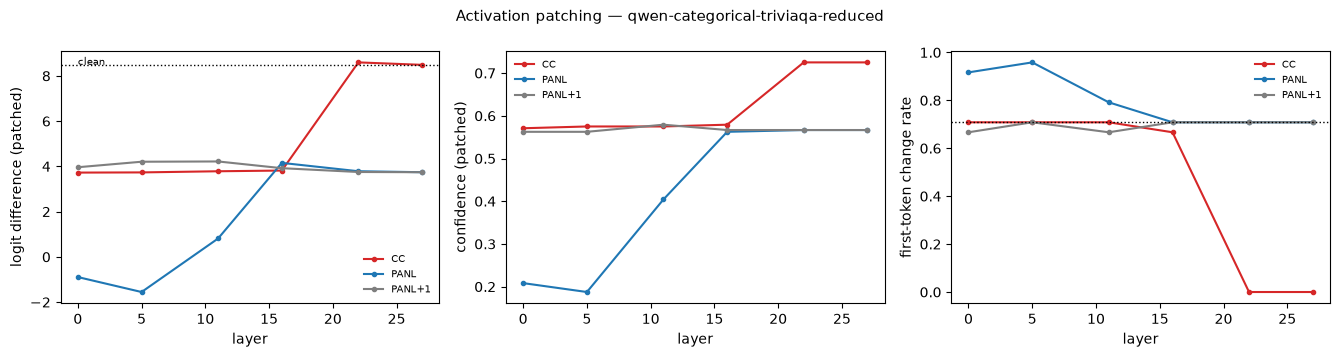

In [10]:
summary = summarize(frame, by=("position", "layer"))
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
for ax, (metric, label) in zip(axes, [
    ("intervened_logit_diff", "logit difference (patched)"),
    ("intervened_confidence", "confidence (patched)"),
    ("token_changed", "first-token change rate"),
]):
    for position, group in recovery.groupby("position"):
        group = group.sort_values("layer")
        column = {"intervened_logit_diff": "logit_diff",
                  "intervened_confidence": "confidence",
                  "token_changed": "token_change_rate"}[metric]
        ax.plot(group["layer"], group[column], marker="o", markersize=3,
                color=plotting.POSITION_COLORS.get(position), label=position)
    ax.set_xlabel("layer")
    ax.set_ylabel(label)
    ax.legend(fontsize=7, frameon=False)
axes[0].axhline(baselines["clean_logit_diff"], color="k", ls=":", lw=1)
axes[0].annotate("clean", (cfg.layers[0], baselines["clean_logit_diff"]), fontsize=7)
axes[2].axhline(baselines["corrupt_token_change_rate"], color="k", ls=":", lw=1)
fig.suptitle(f"Activation patching — {cfg.name}", fontsize=11)
fig.tight_layout()
plotting.save_figure(fig, f"exp2-patching-{cfg.name}")

PosixPath('/scratch/qi/project/results/figures/exp2-recovery-qwen-categorical-triviaqa-reduced.png')

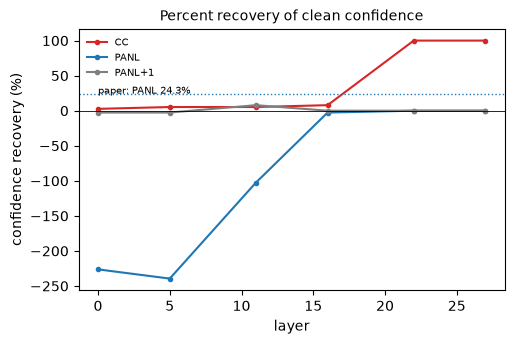

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for position, group in recovery.groupby("position"):
    group = group.sort_values("layer")
    ax.plot(group["layer"], group["confidence_recovery"], marker="o", markersize=3,
            color=plotting.POSITION_COLORS.get(position), label=position)
ax.axhline(0, color="k", lw=0.6)
ax.axhline(E2.PAPER_TARGETS["PANL"]["confidence_recovery"], color="#1f77b4", ls=":", lw=1)
ax.annotate("paper: PANL 24.3%", (cfg.layers[0], 24.3), fontsize=7)
ax.set_xlabel("layer")
ax.set_ylabel("confidence recovery (%)")
ax.set_title("Percent recovery of clean confidence", fontsize=10)
ax.legend(fontsize=7, frameon=False)
plotting.save_figure(fig, f"exp2-recovery-{cfg.name}")

## Peak layers and the paper's numbers (§5.7)

| Position | Logit-diff recovery | Confidence recovery | Token-change recovery | Peak layer |
|---|---|---|---|---|
| **PANL** | partial (Δlogit ≈ 2.3 of ≈ 11.5) | partial (≈ 0.40; 24.3% at L25) | 100% → ≈ 78% | **L25** |
| **CC** | near-complete (≈ 12 by L61) | near-complete (≈ 0.85) | → ≈ 5% | rises only after L30 |
| **PANL+1** | ≈ 0 | ≈ 0 (−1.4%) | ≈ 0 | none |

**Near-ceiling CC recovery at late layers is expected and is *not* the interesting result** —
CC's residual stream feeds the unembedding directly, so patching it late simply bypasses the
corruption. The informative result is the layer-wise pattern.

In [12]:
peaks = {}
for position in ("PANL", "PANL+1", "CC"):
    rows = recovery[recovery["position"] == position]
    peaks[position] = int(rows.loc[rows["confidence_recovery"].idxmax(), "layer"])
paper_peaks = E2.PEAK_LAYERS.get(
    "gemma-categorical" if cfg.model_key == "gemma" else "qwen-categorical", {}
)
best = {p: float(recovery[recovery["position"] == p]["confidence_recovery"].max())
        for p in peaks}
pd.DataFrame([
    {"position": p, "peak layer": peaks[p], "paper peak layer": paper_peaks.get(p),
     "best confidence recovery (%)": round(best[p], 2),
     "paper (%)": E2.PAPER_TARGETS.get(p, {}).get("confidence_recovery")}
    for p in peaks
])

,position,peak layer,paper peak layer,best confidence recovery (%),paper (%)
0,PANL,22,15,0.00,24.3
1,PANL+1,11,27,7.89,-1.4
2,CC,22,27,100.00,NaN


In [13]:
checks = {
    "Q4 patching PANL partially recovers confidence": best["PANL"] > 0,
    "Q4 PANL+1 does not": best["PANL+1"] < best["PANL"],
    "Q3 PANL's recovery peaks before CC's": peaks["PANL"] <= peaks["CC"],
    "recovery is partial, not complete (expected, §5.7 item 3)": best["PANL"] < 100,
}
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")

FAIL  Q4 patching PANL partially recovers confidence
FAIL  Q4 PANL+1 does not
PASS  Q3 PANL's recovery peaks before CC's
PASS  recovery is partial, not complete (expected, §5.7 item 3)


**Interpretation.** Partial PANL recovery is expected, not a failure: the intervention
restores a *single position at a single layer* while corruption keeps propagating everywhere
else, and the paper explicitly positions cached retrieval as the **dominant** rather than the
**sole** pathway. The force of the result is the dissociation — PANL+1 sits one token away,
with near-identical out-of-distribution drift (Experiment 5), and does nothing.